# Stage 3 — Fine-tuning SHViT-S4 on Food-101

This notebook fine-tunes a pretrained SHViT model on Food-101 using `finetune_shvit_food101.py`.

**Before running:** `Runtime → Change runtime type → T4 GPU`

### What this notebook does
1. Verifies GPU, clones repos, installs deps
2. Downloads SHViT-S4 pretrained weights
3. Runs the fine-tuning script for 30 epochs
4. Plots training curves from the CSV log

### Key design decisions (matching original SHViT paper)
| Setting | Value | Source |
|---|---|---|
| Augmentation | RandAugment `rand-m9-mstd0.5-inc1` + RandomErasing p=0.25 | SHViT paper |
| Mixup | alpha=0.8 | SHViT paper |
| CutMix | alpha=1.0 | SHViT paper |
| Label smoothing | 0.1 | SHViT paper |
| Training FP | **Full FP32** forward pass | Matches engine.py (commented-out autocast) |
| Eval FP | AMP autocast | Matches engine.py `evaluate()` |
| Grad clip | norm 0.02 | SHViT paper |
| Optimizer | AdamW, wd=0.025 | SHViT paper |
| LR schedule | Cosine + 5-epoch warmup | SHViT paper |

## 0. GPU check

In [1]:
import torch
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : NVIDIA A100-SXM4-80GB


## 1. (Optional) Mount Drive

Persist the dataset, weights, and checkpoints across sessions.

In [2]:
USE_DRIVE = True

# All artifacts (dataset, pretrained weights, fine-tune outputs, local SSD
# copies) live under a single base directory called ``CV_Research_Paper``.
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/CV_Research_Paper'
else:
    BASE_DIR = '/content/CV_Research_Paper'

DATA_ROOT   = f'{BASE_DIR}/food101_data'
WEIGHTS_DIR = f'{BASE_DIR}/shvit_weights'
OUTPUT_DIR  = f'{BASE_DIR}/shvit_finetune'

WEIGHTS_PATH = f'{WEIGHTS_DIR}/shvit_s4.pth'
print('Base      :', BASE_DIR)
print('Data      :', DATA_ROOT)
print('Weights   :', WEIGHTS_PATH)
print('Output    :', OUTPUT_DIR)

Mounted at /content/drive
Data      : /content/drive/MyDrive/food101_data
Weights   : /content/drive/MyDrive/shvit_weights/shvit_s4.pth
Output    : /content/drive/MyDrive/shvit_finetune


In [3]:
#Use the dataset locally

import shutil, os, time
src = DATA_ROOT  # /content/drive/MyDrive/CV_Research_Paper/food101_data
dst = '/content/CV_Research_Paper/food101_local'

if not os.path.exists(dst):
    print('Copying dataset to local SSD (this takes ~3-5 min, but every epoch will be 5-10x faster)...')
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    t0 = time.time()
    shutil.copytree(src, dst)
    print(f'done in {time.time()-t0:.0f}s')
else:
    print('already copied')

DATA_ROOT = dst  # rebind for the next cells
print('DATA_ROOT now:', DATA_ROOT)

Copying dataset to local SSD (this takes ~3-5 min, but every epoch will be 5-10x faster)...
done in 2590s
DATA_ROOT now: /content/food101_local


## 2. Clone repos and install dependencies

In [4]:
import os

# Clone SHViT (provides the model architecture)
if not os.path.isdir('/content/SHViT'):
    !git clone https://github.com/ysj9909/SHViT.git /content/SHViT

# Clone our project repo to get the fine-tuning script and helpers
if not os.path.isdir('/content/Vision_Project_spring_26'):
    !git clone -b claude/setup-shvit-repo-6OXc1 \
        https://github.com/saif-farid-tech/Vision_Project_spring_26.git \
        /content/Vision_Project_spring_26

import shutil
REPO = '/content/Vision_Project_spring_26'
for fname in [
    'Stage 3: fine-tuning SHViT/finetune_shvit_food101.py',
    'splits.py',
    'metrics.py',
    'augmentation.py',
    'train_val_split_seed42.json',
]:
    shutil.copy(f'{REPO}/{fname}', f'/content/{os.path.basename(fname)}')
    print('Copied:', os.path.basename(fname))


Cloning into '/content/SHViT'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (183/183), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 183 (delta 84), reused 82 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (183/183), 168.52 KiB | 11.23 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Cloning into '/content/Vision_Project_spring_26'...
remote: Enumerating objects: 170, done.
remote: Counting objects: 100% (170/170), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 170 (delta 80), reused 49 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (170/170), 17.26 MiB | 10.44 MiB/s, done.
Resolving deltas: 100% (80/80), done.
Copied: finetune_shvit_food101.py
Copied: splits.py
Copied: metrics.py
Copied: augmentation.py
Copied: train_val_split_seed42.json


In [5]:
# Install SHViT deps. timm must be pinned to 0.5.4 and installed --no-deps
# to avoid downgrading Colab's PyTorch. scikit-image / fvcore / yacs / onnx
# from SHViT's requirements.txt are NOT needed by our fine-tuning wrapper —
# scikit-image==0.19.3 in particular has no wheels for Python 3.12 and would
# fail to build from source.
!pip install -q timm==0.5.4 --no-deps
!pip install -q einops==0.4.1 easydict
print('Dependencies installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 33.8 MB/s eta 0:00:00
Dependencies installed.


## 3. Download SHViT-S4 pretrained weights

In [6]:
os.makedirs(WEIGHTS_DIR, exist_ok=True)
if not os.path.exists(WEIGHTS_PATH):
    !wget -q --show-progress \
        https://github.com/ysj9909/SHViT/releases/download/v1.0/shvit_s4.pth \
        -O {WEIGHTS_PATH}
size_mb = os.path.getsize(WEIGHTS_PATH) / 1e6
print(f'Checkpoint: {size_mb:.1f} MB  ->  {WEIGHTS_PATH}')

Checkpoint: 266.7 MB  ->  /content/drive/MyDrive/shvit_weights/shvit_s4.pth


## 4. Fine-tune SHViT-S4 on Food-101

Food-101 is ~5 GB and downloaded automatically on the first run.

### Estimated runtime on T4
Each epoch: ~5-7 min (75k train images, batch 64, full FP32 forward).  
30 epochs ≈ **2.5–3.5 hours** — use `--epochs 5` first to smoke-test.

> **Tip:** Mount Drive (Cell 1) so checkpoints survive session expiry.

In [7]:
# Quick smoke-test: 2 epochs to verify everything runs
!python /content/finetune_shvit_food101.py \
    --shvit-dir  /content/SHViT \
    --finetune   {WEIGHTS_PATH} \
    --data-root  {DATA_ROOT} \
    --output-dir {OUTPUT_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --epochs 2 \
    --batch-size 64 \
    --lr 1e-4 \
    --num-workers 8

Model: shvit_s4   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_weights/shvit_s4.pth
  Removed (shape mismatch) : ['head.l.weight', 'head.l.bias']
  Missing keys           : ['head.l.weight', 'head.l.bias']
Trainable parameters: 16,184,833
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 2 epochs (starting at 0)
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/2] lr=2.00e-05  train=4.5960  val=4.5007  top1=8.59%  top5=21.02%  (113s)
  -> new best (8.59%), saved to /content/drive/MyDrive/shvit_finetune/best.pth
[  2/2] lr=4.00e-05  train=4.3396  val=3.4658  top1=29.66%  top5=59.9

In [8]:
# Train all 4 SHViT variants sequentially.
# Order: S4 first (largest, do while you're awake to check it works),
#        then S3, S2, S1. Each gets its own output subfolder.

MODELS = ['shvit_s4', 'shvit_s3', 'shvit_s2', 'shvit_s1']

# Per-model weight decay from the SHViT paper.
# (Paper Table 7: S1=0.025, S2=0.032, S3=0.035, S4=0.05)
WEIGHT_DECAY = {
    'shvit_s1': 0.025,
    'shvit_s2': 0.032,
    'shvit_s3': 0.035,
    'shvit_s4': 0.050,
}

for model_name in MODELS:
    model_output_dir = f'{OUTPUT_DIR}/{model_name}'
    weights_path = f'{WEIGHTS_DIR}/{model_name}.pth'

    # Download pretrained weights for this variant if missing
    if not os.path.exists(weights_path):
        print(f'\n=== Downloading {model_name} pretrained weights ===')
        !wget -q --show-progress \
            https://github.com/ysj9909/SHViT/releases/download/v1.0/{model_name}.pth \
            -O {weights_path}

    print(f'\n{"="*60}')
    print(f'Training {model_name}  (wd={WEIGHT_DECAY[model_name]})')
    print(f'{"="*60}')

    # Augmentation (RandAugment / RandomErasing / Mixup / CutMix / smoothing)
    # is owned by augmentation.py — no CLI knobs for it here.

    !python /content/finetune_shvit_food101.py \
        --model      {model_name} \
        --shvit-dir  /content/SHViT \
        --finetune   {weights_path} \
        --data-root  {DATA_ROOT} \
        --output-dir {model_output_dir} \
        --split-file /content/train_val_split_seed42.json \
        --epochs 30 \
        --batch-size 64 \
        --lr 1e-4 \
        --warmup-epochs 5 \
        --weight-decay {WEIGHT_DECAY[model_name]} \
        --clip-grad 0.02 \
        --save-freq 10 \
        --num-workers 8

    print(f'\n=== Finished {model_name} ===\n')

print('All 4 SHViT variants done.')


Training shvit_s4  (wd=0.05)
Model: shvit_s4   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_weights/shvit_s4.pth
  Removed (shape mismatch) : ['head.l.weight', 'head.l.bias']
  Missing keys           : ['head.l.weight', 'head.l.bias']
Trainable parameters: 16,184,833
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 30 epochs (starting at 0)
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/30] lr=2.00e-05  train=4.5968  val=4.5034  top1=7.96%  top5=20.69%  (111s)
  -> new best (7.96%), saved to /content/drive/MyDrive/shvit_finetune/shvit_s4/best.pth
[  2/30] lr=4.00e-05  train=

In [9]:
# Resume from a checkpoint if the session was interrupted
# !python /content/finetune_shvit_food101.py \
#     --shvit-dir  /content/SHViT \
#     --data-root  {DATA_ROOT} \
#     --output-dir {OUTPUT_DIR} \
#     --resume     {OUTPUT_DIR}/checkpoint_010.pth \
#     --epochs 30 \
#     --batch-size 64 \
#     --lr 1e-4 \
#     --num-workers 8

In [13]:
import os, urllib.request

# WEIGHTS_DIR was set in Cell 4 under CV_Research_Paper; reuse it here.
broken_path = f'{WEIGHTS_DIR}/shvit_s3.pth'

# Show current state
if os.path.exists(broken_path):
    print(f'before: {os.path.getsize(broken_path)/1e6:.2f} MB')
    os.remove(broken_path)
    print('deleted broken file')

# Download fresh, raise on failure
url = 'https://github.com/ysj9909/SHViT/releases/download/v1.0/shvit_s3.pth'
print(f'downloading from {url}...')
urllib.request.urlretrieve(url, broken_path)
print(f'after:  {os.path.getsize(broken_path)/1e6:.2f} MB')

before: 0.00 MB
deleted broken file
downloading from https://github.com/ysj9909/SHViT/releases/download/v1.0/shvit_s3.pth...
after:  229.01 MB


In [14]:
# After S2 (and possibly S1) finish — recovery cell for S3
MODELS_TO_REDO = ['shvit_s3']  # add 'shvit_s1' if it also crashed

for model_name in MODELS_TO_REDO:
    weights_path = f'{WEIGHTS_DIR}/{model_name}.pth'
    model_output_dir = f'{OUTPUT_DIR}/{model_name}'

    !python /content/finetune_shvit_food101.py \
        --model      {model_name} \
        --shvit-dir  /content/SHViT \
        --finetune   {weights_path} \
        --data-root  {DATA_ROOT} \
        --output-dir {model_output_dir} \
        --split-file /content/train_val_split_seed42.json \
        --epochs 30 \
        --batch-size 64 \
        --lr 1e-4 \
        --warmup-epochs 5 \
        --weight-decay {WEIGHT_DECAY[model_name]} \
        --clip-grad 0.02 \
        --save-freq 10 \
        --num-workers 8

Model: shvit_s3   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_weights/shvit_s3.pth
  Removed (shape mismatch) : ['head.l.weight', 'head.l.bias']
  Missing keys           : ['head.l.weight', 'head.l.bias']
Trainable parameters: 13,841,622
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()

Fine-tuning for 30 epochs (starting at 0)
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[  1/30] lr=2.00e-05  train=4.5927  val=4.4592  top1=9.14%  top5=24.03%  (102s)
  -> new best (9.14%), saved to /content/drive/MyDrive/shvit_finetune/shvit_s3/best.pth
[  2/30] lr=4.00e-05  train=4.2966  val=3.3626  top1=31.88

## 5. Evaluate the best checkpoint

In [27]:
MODEL = 'shvit_s4'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   {MODEL_DIR}/best.pth \
    --data-root  {DATA_ROOT} \
    --output-dir {MODEL_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --eval

Model: shvit_s4   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_finetune/shvit_s4/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 16,184,833
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 80.73%   top-5: 94.63%


In [28]:
MODEL = 'shvit_s3'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   {MODEL_DIR}/best.pth \
    --data-root  {DATA_ROOT} \
    --output-dir {MODEL_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --eval

Model: shvit_s3   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_finetune/shvit_s3/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 13,841,622
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 80.16%   top-5: 94.56%


In [29]:
MODEL = 'shvit_s2'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   {MODEL_DIR}/best.pth \
    --data-root  {DATA_ROOT} \
    --output-dir {MODEL_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --eval

Model: shvit_s2   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_finetune/shvit_s2/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 11,079,421
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 77.58%   top-5: 93.14%


In [30]:
MODEL = 'shvit_s1'  # change to evaluate other variants
MODEL_DIR = f'{OUTPUT_DIR}/{MODEL}'

!python /content/finetune_shvit_food101.py \
    --model      {MODEL} \
    --shvit-dir  /content/SHViT \
    --finetune   {MODEL_DIR}/best.pth \
    --data-root  {DATA_ROOT} \
    --output-dir {MODEL_DIR} \
    --split-file /content/train_val_split_seed42.json \
    --eval

Model: shvit_s1   Device: cuda
Split (train_val_split_seed42.json): 68,175 train  7,575 val
Pretrained weights loaded from /content/drive/MyDrive/shvit_finetune/shvit_s1/best.pth
  Removed (shape mismatch) : []
Trainable parameters: 6,042,229
/content/finetune_shvit_food101.py:302: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/content/finetune_shvit_food101.py:232: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval  top-1: 74.51%   top-5: 92.24%


## 6. Plot training curves

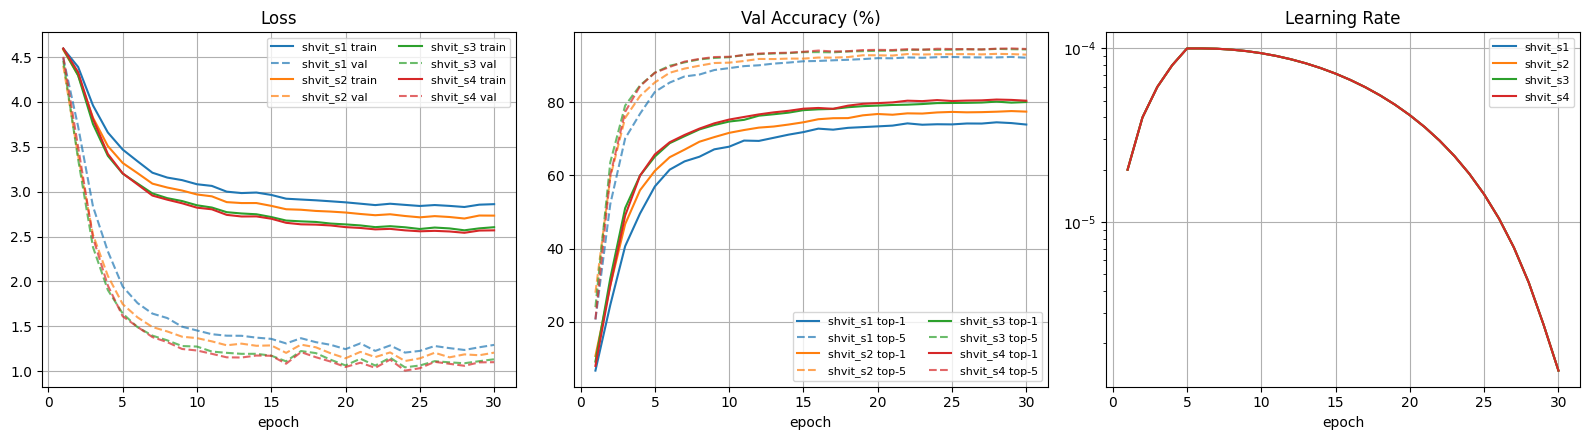


Best val accuracy per model:
model           top-1    top-5  epoch
shvit_s1       74.51%   92.24%     28
shvit_s2       77.58%   93.14%     29
shvit_s3       80.16%   94.56%     28
shvit_s4       80.73%   94.63%     28


In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt

MODELS = ['shvit_s1', 'shvit_s2', 'shvit_s3', 'shvit_s4']
COLORS = {'shvit_s1': 'tab:blue', 'shvit_s2': 'tab:orange',
          'shvit_s3': 'tab:green', 'shvit_s4': 'tab:red'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

summary = []
for model_name in MODELS:
    csv_path = f'{OUTPUT_DIR}/{model_name}/training_log.csv'
    if not os.path.exists(csv_path):
        print(f'[skip] no log for {model_name}')
        continue

    df = pd.read_csv(csv_path)
    color = COLORS[model_name]

    # Loss (train solid, val dashed)
    axes[0].plot(df['epoch'], df['train_loss'], label=f'{model_name} train', color=color)
    axes[0].plot(df['epoch'], df['val_loss'],   label=f'{model_name} val',
                 color=color, linestyle='--', alpha=0.7)

    # Accuracy (top-1 solid, top-5 dashed)
    axes[1].plot(df['epoch'], df['val_top1'] * 100, label=f'{model_name} top-1', color=color)
    axes[1].plot(df['epoch'], df['val_top5'] * 100, label=f'{model_name} top-5',
                 color=color, linestyle='--', alpha=0.7)

    # LR schedule
    axes[2].plot(df['epoch'], df['lr'].astype(float), label=model_name, color=color)

    # Track best for the summary line
    best = df.loc[df['val_top1'].idxmax()]
    summary.append((model_name, best['val_top1']*100, best['val_top5']*100, int(best['epoch'])))

axes[0].set_title('Loss');           axes[0].set_xlabel('epoch')
axes[0].legend(fontsize=8, ncol=2);  axes[0].grid(True)

axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('epoch')
axes[1].legend(fontsize=8, ncol=2);    axes[1].grid(True)

axes[2].set_title('Learning Rate');    axes[2].set_xlabel('epoch')
axes[2].set_yscale('log');             axes[2].legend(fontsize=8); axes[2].grid(True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves_all.png', dpi=120)
plt.show()

# Summary table
print('\nBest val accuracy per model:')
print(f'{"model":<12} {"top-1":>8} {"top-5":>8} {"epoch":>6}')
for name, t1, t5, ep in summary:
    print(f'{name:<12} {t1:>7.2f}% {t5:>7.2f}% {ep:>6}')